# plotting dpCO$_2$ vs fixedCO$_2$ GWP20 / 100 values [metric calculated with the updated ModuleC]

- loads the two excel files (calculated with moduleC) 
- forward-fills `SSP` and `ModelYear`,
- filters the requested SSPs, model years, and horizons,
- builds a 2×3 superplot for CO$_2$, CH$_4$, and N$_2$O.

Marker color encodes **SSP** and fill level encodes **ModelYear**:
- open marker = MY2030
- light fill = MY2040
- solid fill = MY2050

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import matplotlib as mpl
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["mathtext.rm"] = "Times New Roman"
#mpl.rcParams["axes.unicode_minus"] = False
#plt.style.use("tableau-colorblind10")

In [2]:
# -----------------------------
# inputs
# -----------------------------
DP_FILE = Path(r'../dp_approach_ModBvsC/output_dpGWP_dpCO2_modC/dpGWP_dpCO2_CO2CH4N2O_modC.xlsx')
FIXED_FILE = Path(r'../fixed_approach_ModBvcC/output_dpGWP_fixedCO2_modC/dpGWP_fixedCO2_CO2CH4N2O_modC.xlsx')

SELECTED_SSPS = ['119', '126', '245',  '585'] 
SELECTED_MODEL_YEARS = [ 2030, 2040, 2050]
TARGET_YEARS = [20, 100]

In [9]:
# SSP palette for future use
SSP_COLORS = {
    #'119': '#43dde6',
    #'126': '#00a896',
    #'245': '#364f6b',
    #'370': '#7b2cbf',
    #'434': '#f4a261',
    #'460': '#e9c46a',
    #'534': '#2a9d8f',
    #'585': '#fc5185',
    
    # new color scheme: 
     "585": "#d7191c",  # red\n",
     "245": "#fdae61",  # orange\n",
     "126": "#abd9e9",  # light blue\n",
     "119": "#2c7bb6",  # blue\n",
     

}

MARKER_MAP = {
    '119': 'p',
    '126': '^',
    '245': 's',
    '370': 'v',
    '434': 'o',
    '460': 'P',
    '534': '*',
    '585': 'D',
}



# --------------------------------------------------
# https://www.ipcc.ch/report/ar6/wg1/downloads/report/IPCC_AR6_WGI_Chapter07_SM.pdf  (p16)
# --------------------------------------------------
IPCC_GWP = {
    ("CO2_GWP", 20): 1.0,
    ("CO2_GWP", 100): 1.0,
    ("CH4_GWP", 20):  81.2,
    ("CH4_GWP", 100): 27.9,
    ("N2O_GWP", 20):  273.0,
    ("N2O_GWP", 100): 273.0,
}



In [18]:
gas_title = {
    "CO2_GWP": "CO$_2$",
    "CH4_GWP": "CH$_4$",
    "N2O_GWP": "N$_2$O",
}

# --------------------------------------------------
# Axis helpers
# --------------------------------------------------
def get_axis_limits(values, pad_frac: float = 0.08, min_span: float = 0.0):
    values = np.asarray(values, dtype=float)
    vmin = float(np.min(values))
    vmax = float(np.max(values))

    span = vmax - vmin
    if np.isclose(span, 0):
        span = max(abs(vmin) * 0.05, 0.1, min_span)
        return vmin - span / 2, vmax + span / 2

    span = max(span, min_span)
    pad = span * pad_frac
    center = (vmin + vmax) / 2
    half = span / 2 + pad
    return center - half, center + half


def panel_limits(df: pd.DataFrame, gas: str, year: int, ipcc_gwp: dict = IPCC_GWP):
    x = df[f"{gas}_dp"].to_numpy()
    y = df[f"{gas}_fixed"].to_numpy()

    ref = ipcc_gwp[(gas, year)]
    all_vals = np.r_[x, y, ref]

    lo, hi = get_axis_limits(all_vals, pad_frac=0.08)
    return (lo, hi), (lo, hi)


# --------------------------------------------------
# Styling helpers
# --------------------------------------------------
def blend_with_white(color: str, alpha_to_white: float = 0.45):
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    return tuple((1 - alpha_to_white) * rgb + alpha_to_white * white)


def get_my_facecolor(my: int, color: str):
    if my == 2030:
        return "white"
    elif my == 2040:
        return blend_with_white(color, 0.45)
    else:
        return color


# --------------------------------------------------
# Panel background: diagonal line + IPCC star + shading
# --------------------------------------------------
def add_ipcc_guides(ax, xlim, ylim, ipcc_value,
                    light_gray='0.92', dark_gray='0.82',
                    diag_color='0.6'):
    xmin, xmax = xlim
    ymin, ymax = ylim

    # First paint the full panel dark gray:
    # this means "at least one metric > IPCC"
    ax.add_patch(
        plt.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            facecolor=dark_gray,
            edgecolor='none',
            zorder=0,
        )
    )

    # Then carve out the lower-left quadrant in light gray:
    # this means "both metrics < IPCC"
    ax.add_patch(
        plt.Rectangle(
            (xmin, ymin),
            max(ipcc_value - xmin, 0),
            max(ipcc_value - ymin, 0),
            facecolor=light_gray,
            edgecolor='none',
            zorder=0.1,
        )
    )

    # 1:1 diagonal
    diag_lo = max(xmin, ymin)
    diag_hi = min(xmax, ymax)
    ax.plot([diag_lo, diag_hi], [diag_lo, diag_hi],
            color=diag_color, linewidth=1.2, zorder=1)

    # IPCC reference star
    ax.scatter(
        ipcc_value, ipcc_value,
        marker='*',
        s=320,
        facecolors='black',
        edgecolors='black',
        linewidths=1.2,
        zorder=4,
    )

    

# --------------------------------------------------
# Main plotting function
# --------------------------------------------------

def make_superplot_with_ipcc(
    merged: pd.DataFrame,
    selected_ssps,
    selected_model_years,
    target_years=(20, 100),
    ssp_colors=None,
    marker_map=None,
    ipcc_gwp: dict = IPCC_GWP,
    figsize=(17, 10.5),
):
    if ssp_colors is None:
        ssp_colors = {
            "119": "#43dde6",
            "126": "#00a896",
            "245": "#364f6b",
            "370": "#7b2cbf",
            "434": "#f4a261",
            "460": "#e9c46a",
            "534": "#2a9d8f",
            "585": "#fc5185",
        }

    if marker_map is None:
        marker_map = {
            "119": "p",
            "126": "^",
            "245": "s",
            "370": "v",
            "434": "o",
            "460": "P",
            "534": "X",
            "585": "D",
        }

    plot_df = merged[
        merged["SSP"].isin(selected_ssps)
        & merged["ModelYear"].isin(selected_model_years)
        & merged["Year"].isin(target_years)
    ].copy()

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    gas_order = ["CO2_GWP", "CH4_GWP", "N2O_GWP"]

    for row_i, horizon in enumerate(target_years):
        d_year = plot_df[plot_df["Year"] == horizon].copy()

        for col_i, gas in enumerate(gas_order):
            ax = axes[row_i, col_i]
            d_gas = d_year[["SSP", "ModelYear", f"{gas}_dp", f"{gas}_fixed"]].copy()

            x = d_gas[f"{gas}_dp"].to_numpy()
            y = d_gas[f"{gas}_fixed"].to_numpy()
            ipcc_val = ipcc_gwp[(gas, horizon)]

            # dynamic limits including IPCC
            all_vals = np.r_[x, y, ipcc_val]
            lo, hi = get_axis_limits(all_vals, pad_frac=0.08)
            xlim, ylim = (lo, hi), (lo, hi)

            add_ipcc_guides(ax, xlim, ylim, ipcc_val)

            for _, row in d_gas.iterrows():
                ssp = row["SSP"]
                my = int(row["ModelYear"])
                color = ssp_colors.get(ssp, "#444444")
                marker = marker_map.get(ssp, "o")
                face = get_my_facecolor(my, color)

                ax.scatter(
                    row[f"{gas}_dp"],
                    row[f"{gas}_fixed"],
                    marker=marker,
                    s=140,
                    facecolors=face,
                    edgecolors=color,
                    linewidths=1.8,
                    zorder=5,
                )

            ax.set_xlim(*xlim)
            ax.set_ylim(*ylim)
            ax.grid(True, alpha=0.25, zorder=2)
            ax.set_title(f"{gas_title[gas]} — GWP{horizon}", fontsize=17)
            ax.set_xlabel("dpCO$_2$ approach [kg CO$_2$ SSP[x]-MY[t]eq.]", fontsize = 15)
            ax.set_ylabel("fixedCO$_2$ approach [kg CO$_2$ 2019eq.]", fontsize = 15)

    # -----------------------------
    # Main legend: SSP/MY only
    # one column per SSP, rows = MY
    # -----------------------------
    legend_handles = []
    for ssp in selected_ssps:
        color = ssp_colors.get(ssp, "#444444")
        marker = marker_map.get(ssp, "o")

        for my in sorted(selected_model_years):
            face = get_my_facecolor(my, color)
            legend_handles.append(
                Line2D(
                    [0], [0],
                    marker=marker,
                    linestyle="None",
                    markerfacecolor=face,
                    markeredgecolor=color,
                    markeredgewidth=1.8,
                    markersize=10,
                    label=f"SSP{ssp}, MY{my}",
                )
            )

    ncol_main = len(selected_ssps)

    legend_main = fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=ncol_main,
        frameon=True,
        bbox_to_anchor=(0.44, -0.02),
        fontsize=14,
    )

    # -----------------------------
    # separate IPCC legend on the right
    # -----------------------------

    ipcc_handle = Line2D(
        [0], [0],
        marker="*",
        linestyle="None",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=12,
        label="IPCC reference [kg CO$_2$ 2019eq.]",  #[kg CO$_2$ eq.]
    )

    legend_ipcc = fig.legend(
        handles=[ipcc_handle],
        loc="lower center",
        ncol=1,
        frameon=True,
        bbox_to_anchor=(0.88, 0.01),
        fontsize=14,
    )


    """ 
    #to add lower/higher legend: 
    ipcc_handle = Line2D(
    [0], [0],
    marker="*",
    linestyle="None",
    markerfacecolor="black",
    markeredgecolor="black",
    markersize=12,
    label="IPCC reference",
    )
    
    lower_handle = Patch(
        facecolor="0.92",
        edgecolor="0.6",
        label="Lower than IPCC",
    )
    
    higher_handle = Patch(
        facecolor="0.82",
        edgecolor="0.6",
        label="Higher than IPCC",
    )
    
    legend_ipcc = fig.legend(
        handles=[ipcc_handle, lower_handle, higher_handle],
        loc="lower center",
        ncol=1,
        frameon=True,
        bbox_to_anchor=(0.89, -0.02),
        fontsize=10,
        handlelength=1.4,
        labelspacing=0.8,
        borderpad=0.8,
    )
    """ 
    
    fig.add_artist(legend_main)
    fig.add_artist(legend_ipcc)

    fig.tight_layout(rect=[0, 0.08, 1, 1])
    return fig, plot_df
    

### load data

In [5]:
def load_metric_table(path: Path) -> pd.DataFrame:
    df = pd.read_excel(path)
    df[['SSP', 'ModelYear']] = df[['SSP', 'ModelYear']].ffill()
    df['SSP'] = df['SSP'].astype(int).astype(str)
    df['ModelYear'] = df['ModelYear'].astype(int)
    return df

def blend_with_white(color: str, alpha_to_white: float = 0.45):
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    return tuple((1 - alpha_to_white) * rgb + alpha_to_white * white)



def get_axis_limits(values, pad_frac: float = 0.08, min_span: float = 0.0):
    values = np.asarray(values, dtype=float)
    vmin = float(np.min(values))
    vmax = float(np.max(values))

    span = vmax - vmin
    if np.isclose(span, 0):
        span = max(abs(vmin) * 0.05, 0.1, min_span)
        return vmin - span / 2, vmax + span / 2

    span = max(span, min_span)
    pad = span * pad_frac
    center = (vmin + vmax) / 2
    half = span / 2 + pad
    return center - half, center + half

def panel_limits(df: pd.DataFrame, gas: str):
    x = df[f"{gas}_dp"].to_numpy()
    y = df[f"{gas}_fixed"].to_numpy()
    all_vals = np.r_[x, y]

    lo, hi = get_axis_limits(all_vals, pad_frac=0.08)
    return (lo, hi), (lo, hi)

In [6]:
dp = load_metric_table(DP_FILE)
fixed = load_metric_table(FIXED_FILE)
merged = dp.merge(fixed, on=['SSP', 'ModelYear', 'Year'], suffixes=('_dp', '_fixed'))

plot_df = merged[
    merged['SSP'].isin(SELECTED_SSPS)
    & merged['ModelYear'].isin(SELECTED_MODEL_YEARS)
    & merged['Year'].isin(TARGET_YEARS)
].copy()

#display(plot_df[['SSP', 'ModelYear', 'Year', 'CO2_GWP_dp', 'CO2_GWP_fixed', 'CH4_GWP_dp', 'CH4_GWP_fixed', 'N2O_GWP_dp', 'N2O_GWP_fixed']])

In [7]:
display(plot_df[['SSP', 'ModelYear', 'Year', 'CO2_GWP_dp', 'CO2_GWP_fixed', 'CH4_GWP_dp', 'CH4_GWP_fixed', 'N2O_GWP_dp', 'N2O_GWP_fixed']])

,SSP,ModelYear,Year,CO2_GWP_dp,CO2_GWP_fixed,CH4_GWP_dp,CH4_GWP_fixed,N2O_GWP_dp,N2O_GWP_fixed
20,119,2030,20,1,0.988144,92.480493,89.671354,212.952641,207.088231
100,119,2030,100,1,1.019911,28.693328,29.385897,180.804766,182.275695
121,119,2040,20,1,0.973543,96.204022,91.993583,210.118052,201.840383
201,119,2040,100,1,0.993256,29.862711,29.724466,180.311438,177.222163
222,119,2050,20,1,0.974599,97.530953,93.359489,205.384429,197.150047
302,119,2050,100,1,0.982755,30.122859,29.775975,177.166581,172.729300
323,126,2030,20,1,0.990227,89.375902,86.921284,212.463743,207.188046
403,126,2030,100,1,1.063739,26.518413,28.264379,173.565456,182.387132
424,126,2040,20,1,0.959814,94.352633,88.809078,214.376079,202.734690
504,126,2040,100,1,1.014692,28.070516,28.608028,177.285922,178.036441


### plot and save

Saved figure to: relative_GWP20-100_USEtox-type_fig/v2_gwp20-100_dp_vs_fixed_CO2.png


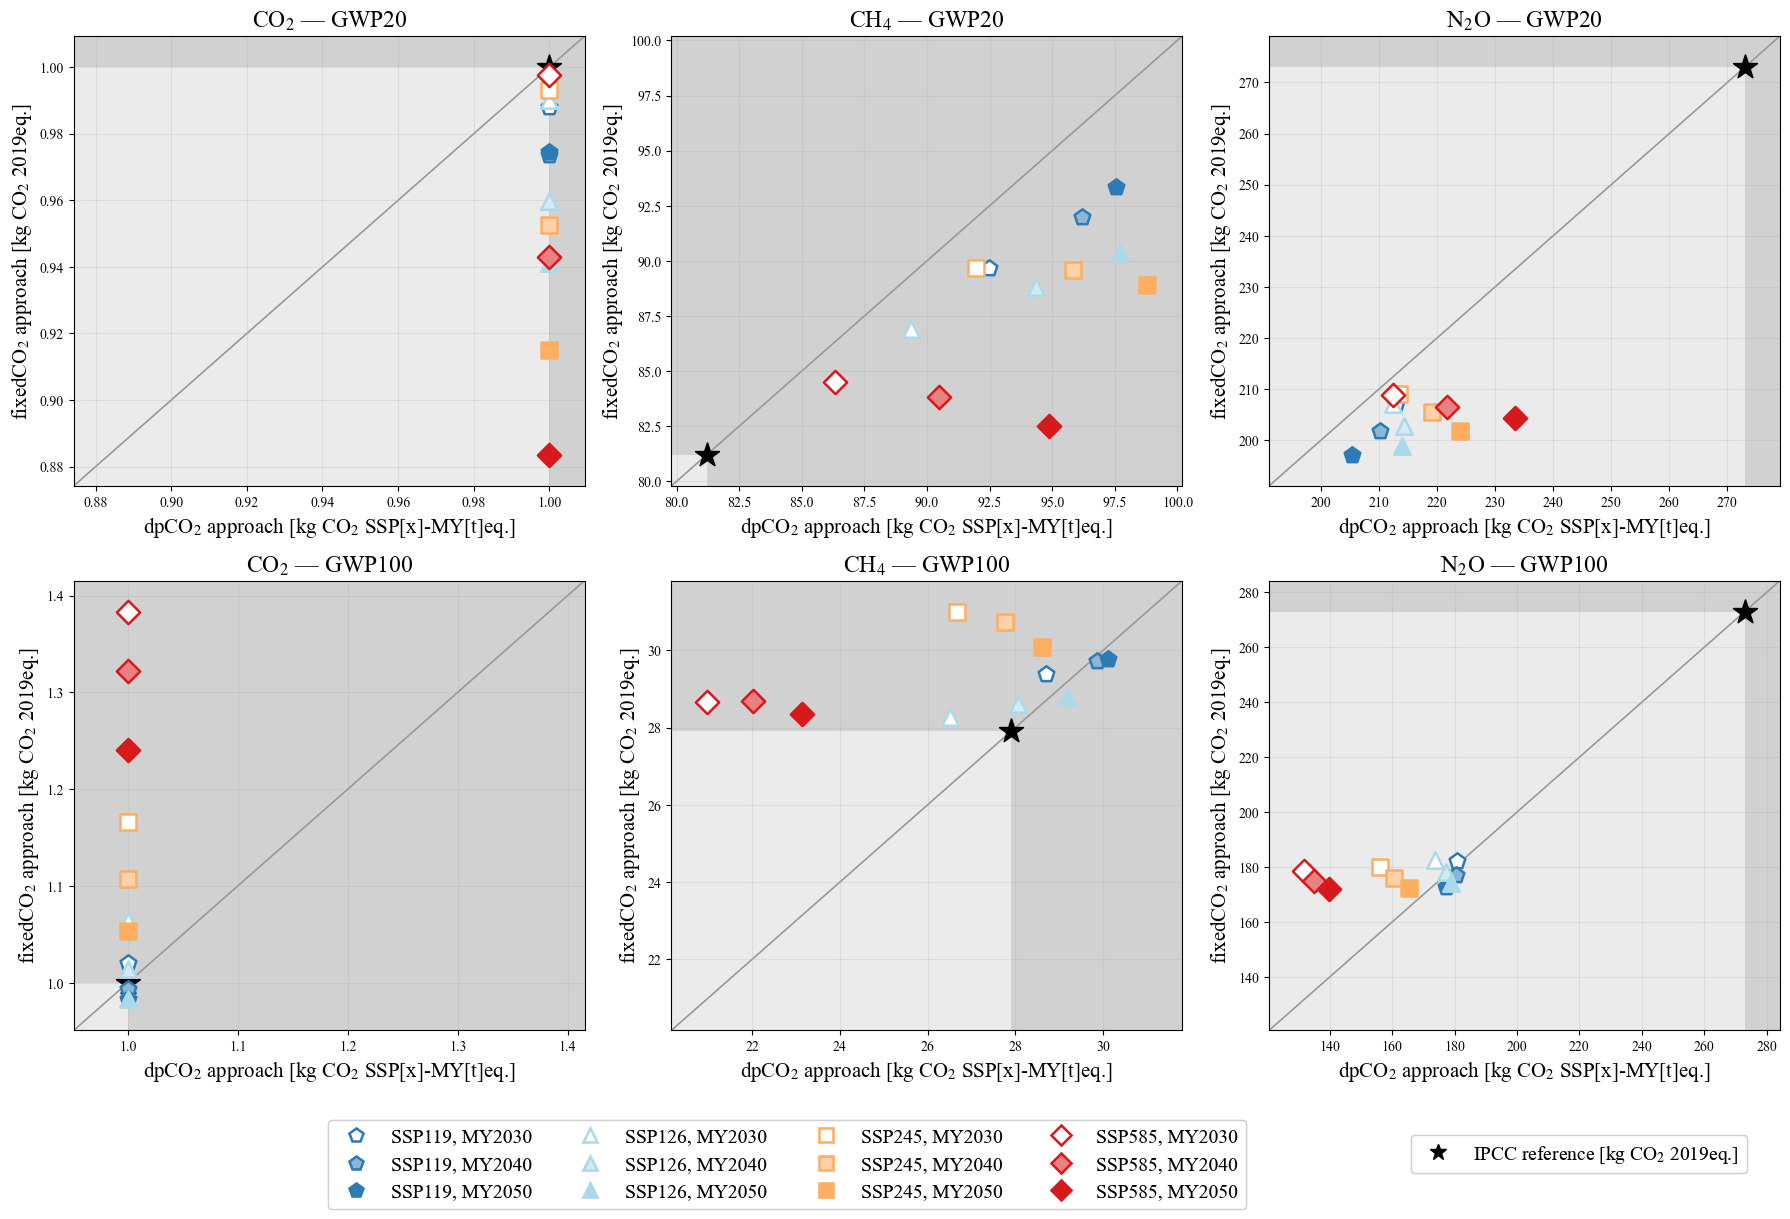

In [19]:
fig, plot_df = make_superplot_with_ipcc(
    merged=merged,
    selected_ssps=SELECTED_SSPS,
    selected_model_years=SELECTED_MODEL_YEARS,
    target_years=TARGET_YEARS,
    ssp_colors=SSP_COLORS,
    marker_map=MARKER_MAP,
    ipcc_gwp=IPCC_GWP,
    figsize=(18, 12),
)

output_path = "relative_GWP20-100_USEtox-type_fig/v2_gwp20-100_dp_vs_fixed_CO2.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()

### N2O GWP with the old ModuleB:
- dpLCIA/LCIA/5_CFanal_comp_dpGWP_pd_vs_fixedAGWPCO2.ipynb 
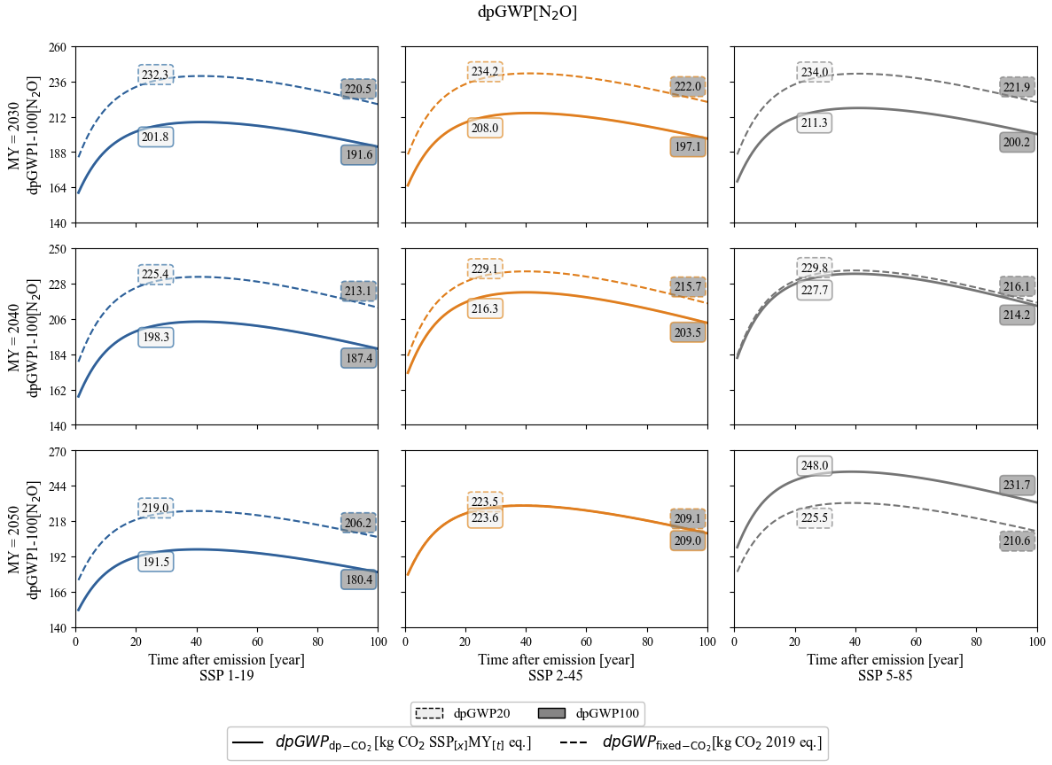


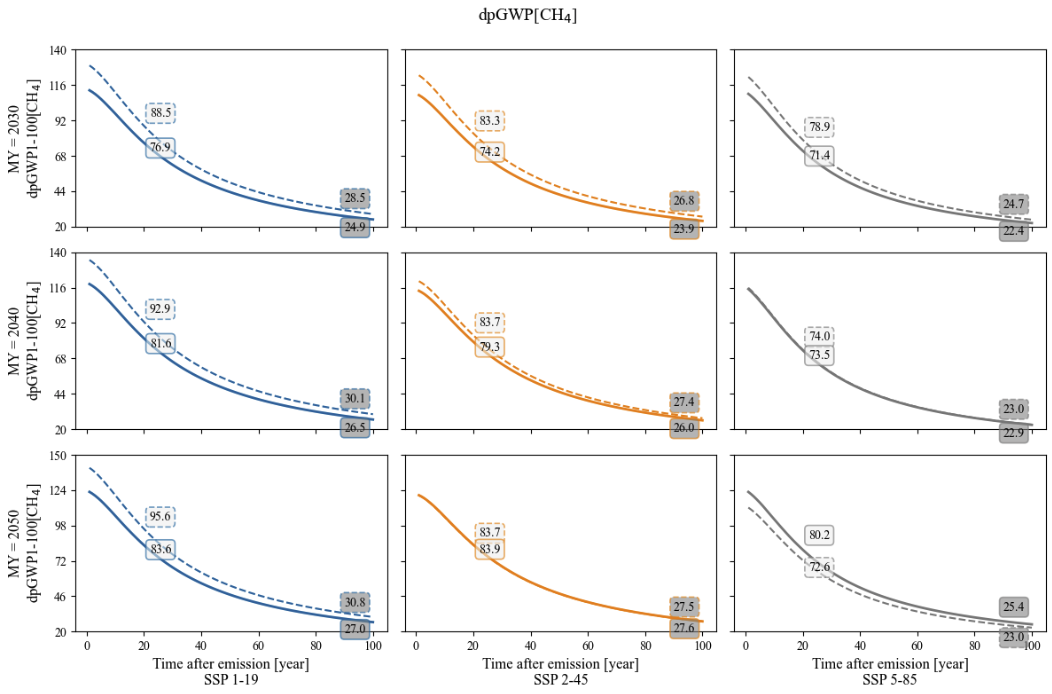